#### notebook: *gaia_guery_activity_updated_dr3_v2*

## How to Query and Plot data from the Gaia Sattelite Database?</h1>

Here are some useful links 
- [European Space Agency Gaia Mission - Writing Queries Turorial](https://www.cosmos.esa.int/web/gaia-users/archive/writing-queries)
- [Gaia's Hertzsprung-Russel Diagram](https://sci.esa.int/web/gaia/-/60198-gaia-hertzsprung-russell-diagram)
- [Color Index](https://en.wikipedia.org/wiki/Color_index)

In the examples below we will query ***half-a-million stars within 200 Parsecs of the sun and plot it in a Hertzsprung-Russel Diagram (HRD)***


In [1]:
#!echo $PATH  # for debugging as needed

In [2]:
# Data Folder
data_folder="data_folder"
!ls -l {data_folder}

total 31220
drwxr-xr-x 2 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490     4096 Jan  7 21:16 archive
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490  1229719 Jan  7 21:18 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490   209702 Jan  8 01:56 gaia-hrd-dr3-200pc_10000_stars.csv.png
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490 30519125 Jan  8 01:38 gaia-hrd-dr3-200pc_250000_stars.csv


In [3]:
#!pip list  # for debugging as needed

In [4]:
#EXECUTE THIS CELL THEN RESTART KERNEL
#!pip install astroquery  # for debugging as needed

In [5]:
# Create Access to the Gaia Database
from astroquery.gaia import Gaia

# Load Tables from the Gai Database
tables = Gaia.load_tables(only_names=True)

# Print the Table Names in the Gaia Database
for table in tables:
    print(table.name)

INFO: Retrieving tables... [astroquery.utils.tap.core]
INFO: Parsing tables... [astroquery.utils.tap.core]
INFO: Done. [astroquery.utils.tap.core]
external.apassdr9
external.catwise2020
external.gaiadr2_astrophysical_parameters
external.gaiadr2_geometric_distance
external.gaiaedr3_distance
external.gaiaedr3_gcns_main_1
external.gaiaedr3_gcns_rejected_1
external.gaiaedr3_spurious
external.gaia_eso_survey
external.galex_ais
external.lamost_dr9_lrs
external.lamost_dr9_mrs
external.ravedr5_com
external.ravedr5_dr5
external.ravedr5_gra
external.ravedr5_on
external.ravedr6
external.sdssdr13_photoprimary
external.skymapperdr1_master
external.skymapperdr2_master
external.tmass_xsc
external.xgboost_table1
external.xgboost_table2
gaiadr1.aux_qso_icrf2_match
gaiadr1.ext_phot_zero_point
gaiadr1.allwise_best_neighbour
gaiadr1.allwise_neighbourhood
gaiadr1.gsc23_best_neighbour
gaiadr1.gsc23_neighbourhood
gaiadr1.ppmxl_best_neighbour
gaiadr1.ppmxl_neighbourhood
gaiadr1.sdss_dr9_best_neighbour
gaiadr1

In [6]:
# Get Gaia Sources Table
meta = Gaia.load_table('gaiadr3.gaia_source')
print(meta)

TAP Table name: gaiadr3.gaiadr3.gaia_source
Description: This table has an entry for every Gaia observed source as published with this data release. It contains the basic source parameters, in their final state as processed by the Gaia Data Processing and Analysis Consortium from the raw data coming from the spacecraft. The table is complemented with others containing information specific to certain kinds of objects (e.g.~Solar--system objects, non--single stars, variables etc.) and value--added processing (e.g.~astrophysical parameters etc.). Further array data types (spectra, epoch measurements) are presented separately via Datalink resources.
Num. columns: 152


In [7]:
# Print all columns in the Gaia Source Table
for column in meta.columns:
    print(column.name)

solution_id
designation
source_id
random_index
ref_epoch
ra
ra_error
dec
dec_error
parallax
parallax_error
parallax_over_error
pm
pmra
pmra_error
pmdec
pmdec_error
ra_dec_corr
ra_parallax_corr
ra_pmra_corr
ra_pmdec_corr
dec_parallax_corr
dec_pmra_corr
dec_pmdec_corr
parallax_pmra_corr
parallax_pmdec_corr
pmra_pmdec_corr
astrometric_n_obs_al
astrometric_n_obs_ac
astrometric_n_good_obs_al
astrometric_n_bad_obs_al
astrometric_gof_al
astrometric_chi2_al
astrometric_excess_noise
astrometric_excess_noise_sig
astrometric_params_solved
astrometric_primary_flag
nu_eff_used_in_astrometry
pseudocolour
pseudocolour_error
ra_pseudocolour_corr
dec_pseudocolour_corr
parallax_pseudocolour_corr
pmra_pseudocolour_corr
pmdec_pseudocolour_corr
astrometric_matched_transits
visibility_periods_used
astrometric_sigma5d_max
matched_transits
new_matched_transits
matched_transits_removed
ipd_gof_harmonic_amplitude
ipd_gof_harmonic_phase
ipd_frac_multi_peak
ipd_frac_odd_win
ruwe
scan_direction_strength_k1
scan_di

In [8]:
# Create a Synchronous (immediate submit) Query Job 
# for just the top 10 rows from the table retrieving
# columns source_id, ra, dec, parallax (How did I know the column names ??)
# note that it validates and gives you the units, description and bad rows!
query1 = """SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source
"""
job1 = Gaia.launch_job(query1)
job1
print(job1)

<Table length=10>
   name    dtype  unit                            description                             n_bad
--------- ------- ---- ------------------------------------------------------------------ -----
SOURCE_ID   int64      Unique source identifier (unique within a particular Data Release)     0
       ra float64  deg                                                    Right ascension     0
      dec float64  deg                                                        Declination     0
 parallax float64  mas                                                           Parallax     3
Jobid: None
Phase: COMPLETED
Owner: None
Output file: 1736301493616O-result.vot.gz
Results: None


In [9]:
print(query1)

SELECT 
TOP 10
source_id, ra, dec, parallax 
FROM gaiadr3.gaia_source



In [10]:
# This statement below retrieves the result (note only 10 rows retrieved because that is what we asked for!)
results = job1.get_results()
results

SOURCE_ID,ra,dec,parallax
,deg,deg,mas
int64,float64,float64,float64
5860087192962627200,187.41261764150505,-66.40255364989628,--
5860087192962633216,187.39275967188664,-66.40638178674094,0.3027758725252933
5860087192962634880,187.4068935531616,-66.40594585027829,--
5860087192962646144,187.39123188245128,-66.41251721804964,0.453275332404235
5860087192962647424,187.38689355130973,-66.41322534462168,-0.9050653223773661
5860087192962649984,187.39681890732865,-66.4134947666449,--
5860087192962650112,187.38177690993777,-66.41456056252893,-0.967213473914522
5860087192962652928,187.38185246495195,-66.41557118620305,1.2150804217502216


In [11]:
# Create a Asynchronous (scheduled submit) Query Job
# for just the top 2000 rows from the table retrieving
# columns source_id, ra, dec, pmra, pmdec, parallax, bp_rp 
# with a WHERE clause
# note that it validates and gives you the units, description and bad rows!
# What does Parallax < 1 mean in terms of distance ??  d = 1/p
query2 = """SELECT 
TOP 2000
source_id, ra, dec, pmra, pmdec, parallax, 1000/parallax as dist, bp_rp
FROM gaiadr3.gaia_source
WHERE 1000/parallax < 200 and 1000/parallax > 150
"""
job2 = Gaia.launch_job_async(query2)
print(job2)

INFO: Query finished. [astroquery.utils.tap.core]
<Table length=2000>
   name    dtype    unit                              description                             n_bad
--------- ------- -------- ------------------------------------------------------------------ -----
SOURCE_ID   int64          Unique source identifier (unique within a particular Data Release)     0
       ra float64      deg                                                    Right ascension     0
      dec float64      deg                                                        Declination     0
     pmra float64 mas / yr                         Proper motion in right ascension direction     0
    pmdec float64 mas / yr                             Proper motion in declination direction     0
 parallax float64      mas                                                           Parallax     0
     dist float64                                                                                 0
    bp_rp float32      mag    

In [12]:
# This statement below retrieves the result (note 2000 rows retrieved because that is what we asked for!)
results = job2.get_results()
results

SOURCE_ID,ra,dec,pmra,pmdec,parallax,dist,bp_rp
,deg,deg,mas / yr,mas / yr,mas,,mag
int64,float64,float64,float64,float64,float64,float64,float32
4362228584100072448,261.91090165826785,-5.115256429780534,-7.331442692628988,-0.6768272710178875,5.556439615779968,179.97136100607622,1.763464
5860117700098979584,186.01102308954052,-66.53338690200599,21.80394504288121,-3.351862814522886,5.283479026280048,189.26922867035066,3.0952148
4362228687174710656,261.9162622969519,-5.104108287109869,-4.589083991952757,-2.5120607392368353,5.69909615147899,175.46642018673205,1.7835655
4361906044936582912,262.34473024261155,-6.149994753337046,-61.679052398898385,-10.880129849209554,6.642911513114381,150.5364023027867,2.2651548
5860251874896080640,188.9426323228734,-65.7633421634654,-9.135483927284936,-3.6783447174825867,5.540375229279546,180.4931901931915,1.8294563
4361906873866587136,262.31797641979654,-6.1289103601566755,-4.277346505057576,-40.73729586556945,5.190032233443401,192.6770307044,1.590456
5860224150884949504,190.078986077161,-65.70018206604948,-9.636424649204487,-5.166097268231414,5.178157423869662,193.1188873073494,1.9810314
4362570257336435712,263.5460597856184,-4.429719568561691,10.742104369212582,-21.952625276379067,6.660197491406188,150.1456978250756,1.6508121


In [13]:
# Here I am defining a python function to execute a asynchronous query which I can then pass to a Job
def send_radial_gaia_query(query_size=500, distance=200, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 3: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to Gaia.launch_job_async method.
    """
    query3 = (" SELECT"
            " TOP {}".format(query_size)+
            " source_id, ra, dec, parallax, bp_rp, phot_g_mean_mag+5*log10(parallax)-10 as mg, 1000/parallax as dist"
            " FROM gaiadr3.gaia_source"
            " WHERE parallax > 0"
#            " AND bp_rp > -0.75"
#            " AND bp_rp < 6"
            " AND 1000/parallax <= {}".format(distance)
    )


    
    job = Gaia.launch_job_async(query3, **kwargs)
    return job

In [14]:
job3 = send_radial_gaia_query(query_size=10000,distance=200)  # Query 10000 alhough default is 500 stars
results = job3.get_results()
results

INFO: Query finished. [astroquery.utils.tap.core]


SOURCE_ID,ra,dec,parallax,bp_rp,mg,dist
,deg,deg,mas,mag,,
int64,float64,float64,float64,float32,float64,float64
5966227310986979840,254.78490923738585,-42.674126771276626,6.0135798962718585,3.220398,13.586093207002072,166.29029916438856
2162633926122853376,316.12565374118907,45.03885929889618,9.064323712423503,1.6030941,15.367029818234933,110.32262656610625
5965848662369882752,257.9374171462713,-41.362877403462626,6.884745284279724,2.214079,14.309943765506539,145.2486560807629
5966031632272522496,257.4693875921614,-41.26047020659543,5.022254684290299,2.6011047,14.037111231500727,199.11375723895833
2162633994821928832,316.1550902916436,45.04654640051916,7.13803205672702,3.275858,12.697435011653383,140.0946356156499
5966083893447641088,257.1742658817464,-41.0654448230782,5.605788872633288,3.1576576,14.068588806685735,178.38702504153633
5966031632293940864,257.4676467288675,-41.2595978982431,5.3319019482803,2.376068,13.715511235362914,187.55033564008625
5966227615919379072,254.76632330103098,-42.638864415587186,5.647760389346515,1.1008825,5.848117849875607,177.06133600963673


In [15]:
!ls -l data_folder

total 31220
drwxr-xr-x 2 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490     4096 Jan  7 21:16 archive
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490  1229719 Jan  7 21:18 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490   209702 Jan  8 01:56 gaia-hrd-dr3-200pc_10000_stars.csv.png
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490 30519125 Jan  8 01:38 gaia-hrd-dr3-200pc_250000_stars.csv


In [16]:
# Here I am defining a job for the same asynchronous within a try-except block
# This will first look for a previoysly stored file (try-block)
# if it does not exist it will execute the query (except-bloclk)

import numpy as np
from astropy import log

num_stars = 10000
small_datafile_name = data_folder+"/gaia-hrd-dr3-200pc_%d_stars.csv" % (num_stars)
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {small_datafile_name}\n")
    #gaiarec = np.recfromcsv(small_datafile_name)
    gaiarec = np.genfromtxt(small_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {small_datafile_name}\n")
    print(bp_rp, mg, dist)
except OSError:
    job4 = send_radial_gaia_query(dump_to_file=True, output_format="csv",
                                 output_file=small_datafile_name,
                                 query_size=num_stars,distance=200)
    results = job4.get_results()
    bp_rp = results['bp_rp'].data
    mg = results['mg'].data
    dist = results['dist'].data
    print(f"querying and saving NEW results to {small_datafile_name}\n")
    print(bp_rp, mg, dist)


INFO: Getting the DR3 results on nearby (d < 200 pc) stars stored in data_folder/gaia-hrd-dr3-200pc_10000_stars.csv
 [unknown]
reading OLD results from previously existng data_folder/gaia-hrd-dr3-200pc_10000_stars.csv

[1.0573311 0.7897301 1.6260052 ... 1.1759453 1.4143543 2.209402 ] [14.39775591 14.95705946  7.17350968 ... 12.95175185 14.49928315
 14.02777958] [196.81887874 131.38817889 148.67898479 ... 185.01873183 186.41410012
 189.17962084]


In [17]:
!ls -ltr {data_folder}
data_folder        

total 31220
drwxr-xr-x 2 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490     4096 Jan  7 21:16 archive
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490  1229719 Jan  7 21:18 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490 30519125 Jan  8 01:38 gaia-hrd-dr3-200pc_250000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490   209702 Jan  8 01:56 gaia-hrd-dr3-200pc_10000_stars.csv.png


'data_folder'

#### Find the CSV file and double-click it!
#### Once you have done this - go back to the previous Cell and execute once more and see what happens!!
#### Can you describe what happened ??
#### Now let's plot it!!

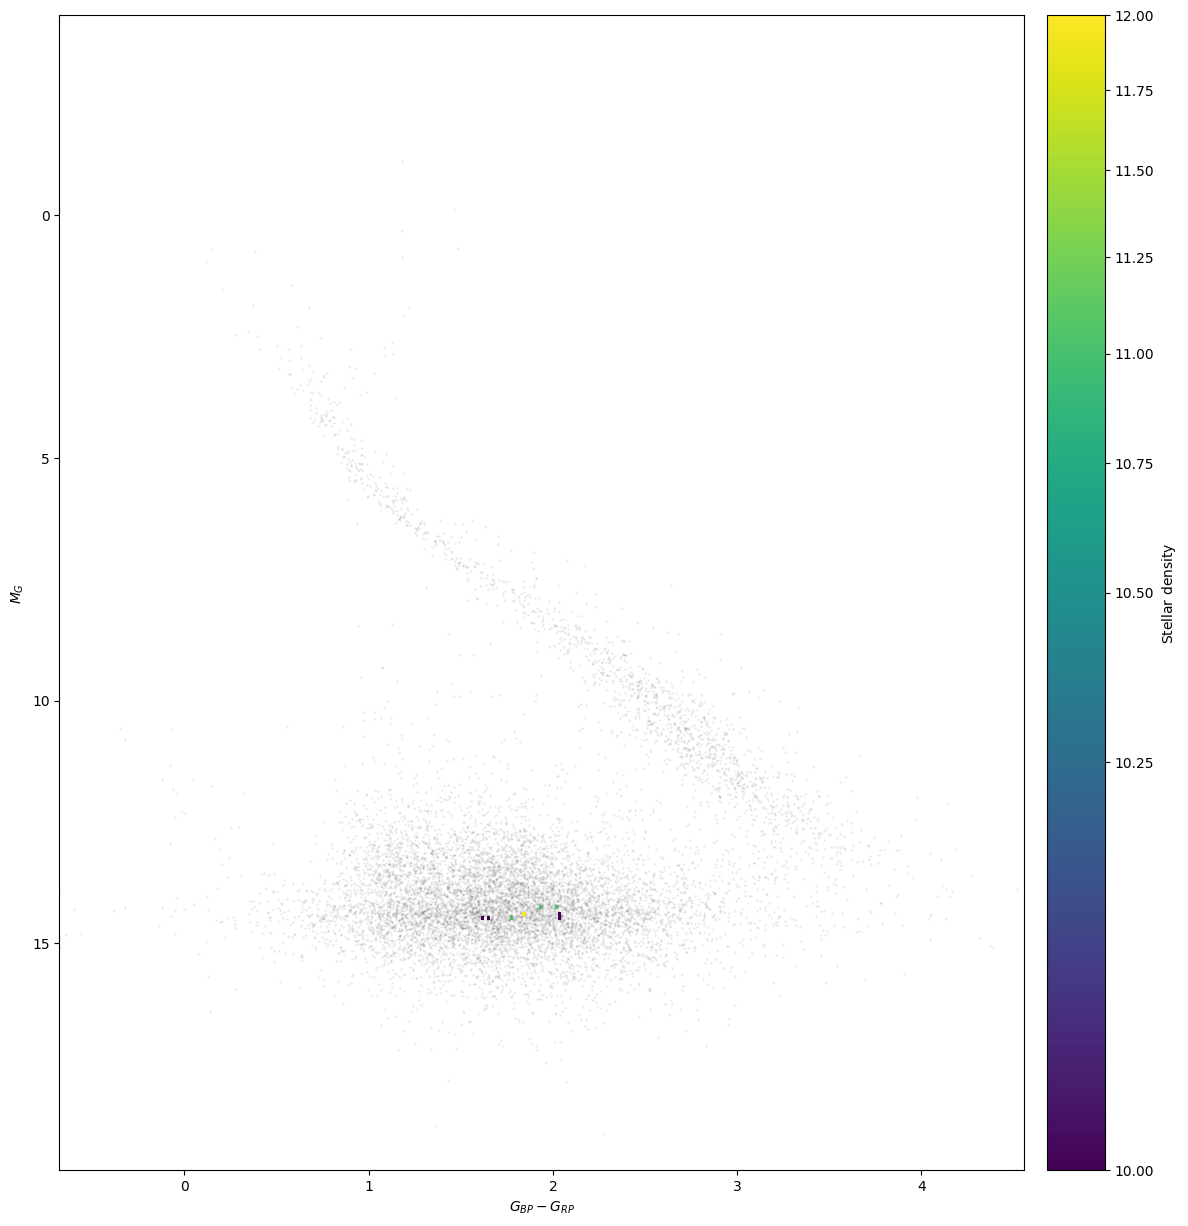

In [18]:
# plot the H-R diagram for the 10000 stars within 200 pc from the Sun
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{small_datafile_name}.png", dpi=140)

In [19]:
# Here I am redefining the send_radial_gaia_query function with a lot more filters!
def send_radial_gaia_query_with_filters(query_size=500, distance=200, **kwargs):
    """
    Sends an archive query for d < 200 pc, with additional filters taken from
    Gaia Data Release 2: Observational Hertzsprung-Russell diagrams (Sect. 2.1)
    Gaia Collaboration, Babusiaux et al. (2018)
    (https://doi.org/10.1051/0004-6361/201832843)

    NOTE: 10000000 is a maximum query size (~76 MB / column)

    Additional keyword arguments are passed to TapPlus.launch_job_async method.
    """
    #from astroquery.utils.tap.core import TapPlus
    #from astroquery.gaia import Gaia

    #gaia = TapPlus(url="http://gea.esac.esa.int/tap-server/tap")
    query4 = (" SELECT"
            " TOP {}".format(query_size)+
            " source_id, ra, dec, parallax, bp_rp, phot_g_mean_mag+5*log10(parallax)-10 as mg, 1000/parallax as dist"
            " FROM gaiadr3.gaia_source"
            " WHERE parallax > 0"
            " AND bp_rp > -0.75"
            " AND bp_rp < 6"
            " AND visibility_periods_used > 8"
            " AND phot_g_mean_flux_over_error > 50"
            " AND phot_bp_mean_flux_over_error > 20"
            " AND phot_rp_mean_flux_over_error > 20"  
            " and phot_bp_rp_excess_factor <"
            " 1.3+0.06*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and phot_bp_rp_excess_factor >"
            " 1.0+0.015*power(phot_bp_mean_mag-phot_rp_mean_mag,2)"
            " and astrometric_chi2_al/(astrometric_n_good_obs_al-5)<"
            "1.44*greatest(1,exp(-0.4*(phot_g_mean_mag-19.5)))"            " AND 1000/parallax <= {}".format(distance)
    )    


    job = Gaia.launch_job_async(query4, **kwargs)

    return job

In [20]:
# Here I am defining a new with filters job for the same asynchronous within the try-except block
# This time for 100000 stars now including the filters
# This will first look for a reviosly stored file (try-block)
# if it does not exist it will execute the query (except-block)
import numpy as np
from astropy import log

# the query runs for a while, better ensure we have those data saved
num_stars = 250000
large_datafile_name = data_folder+"/gaia-hrd-dr3-200pc_%d_stars.csv" % (num_stars)
try:
    log.info(f"Getting the DR3 results on nearby (d < 200 pc) stars stored in {large_datafile_name}\n")
    #gaiarec = np.recfromcsv(large_datafile_name)
    gaiarec = np.genfromtxt(large_datafile_name, delimiter=',', names=True, dtype=None)
    #bp_rp, mg, dist = gaiarec.bp_rp, gaiarec.mg, gaiarec.dist
    bp_rp, mg, dist = gaiarec["bp_rp"], gaiarec["mg"], gaiarec["dist"]
    print(f"reading OLD results from previously existng {large_datafile_name}\n")
    print(bp_rp, mg, dist)    
except OSError:
    job = send_radial_gaia_query_with_filters(dump_to_file=True, output_format="csv"
                                 ,output_file=large_datafile_name
                                 ,query_size=num_stars
    )
    r = job.get_results()
    bp_rp = r['bp_rp'].data
    mg = r['mg'].data
    dist = r['dist'].data
    print(f"querying and saving NEW results to {large_datafile_name}\n")
    print(bp_rp, mg, dist)

INFO: Getting the DR3 results on nearby (d < 200 pc) stars stored in data_folder/gaia-hrd-dr3-200pc_250000_stars.csv
 [unknown]
reading OLD results from previously existng data_folder/gaia-hrd-dr3-200pc_250000_stars.csv

[2.870368  2.6218653 3.1099453 ... 3.2061977 2.6147184 2.88616  ] [11.61470613 10.82361364 11.3980392  ... 12.51338126 10.71099021
 11.24363288] [124.0049676  160.05186222 159.20016772 ... 119.52876842 148.62276238
  90.50400258]


In [21]:
!ls -ltr {data_folder}

total 31220
drwxr-xr-x 2 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490     4096 Jan  7 21:16 archive
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490  1229719 Jan  7 21:18 gaia-hrd-dr3-200pc_10000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490 30519125 Jan  8 01:38 gaia-hrd-dr3-200pc_250000_stars.csv
-rw-r--r-- 1 jupyter-saraswathi.venkata-af490 jupyter-saraswathi.venkata-af490   209702 Jan  8 01:58 gaia-hrd-dr3-200pc_10000_stars.csv.png


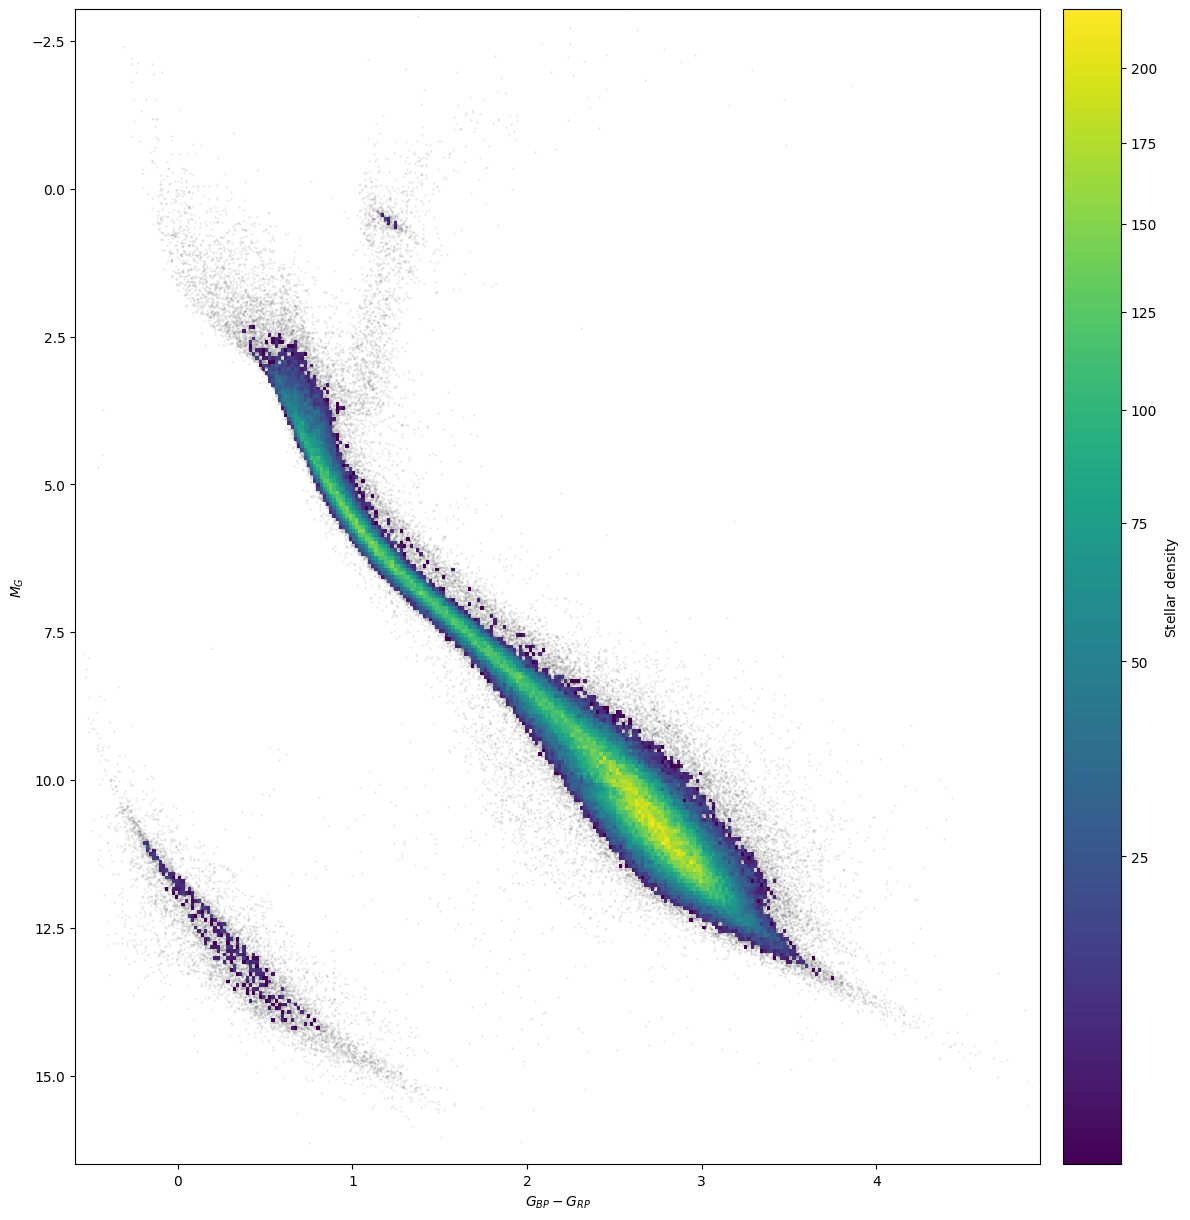

In [22]:
# plot the H-R diagram for stars within 200 pc from the Sun
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.savefig(f"{large_datafile_name}.png", dpi=140)

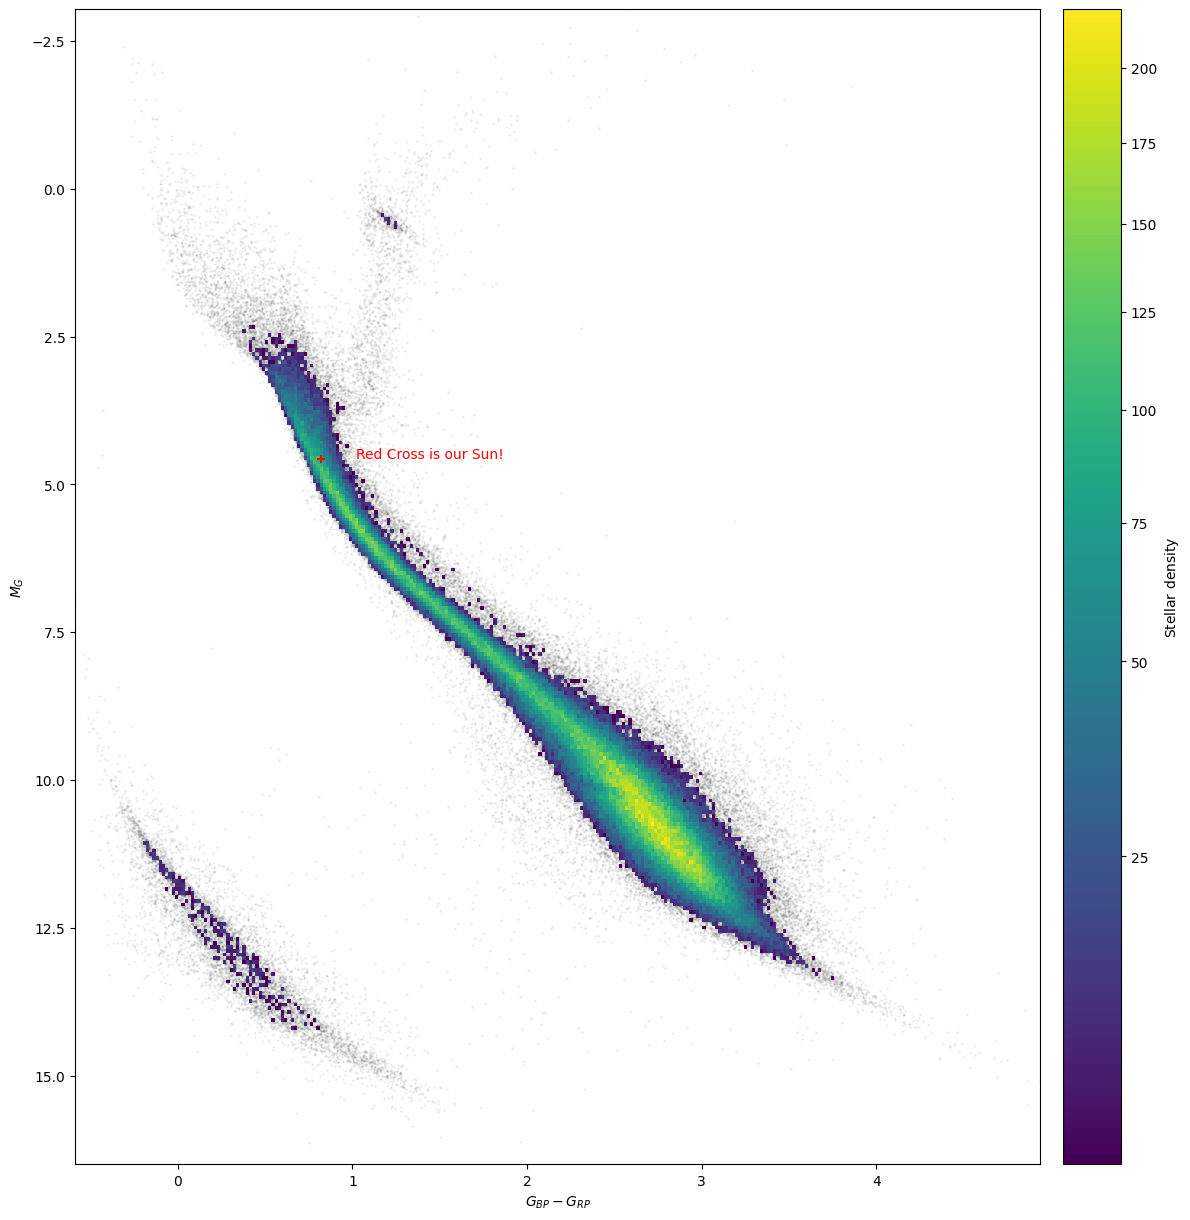

In [29]:
%matplotlib inline
import math
import matplotlib.pyplot as plt
from matplotlib import colors
plt.rc('text', usetex=False)

fig, ax = plt.subplots(figsize=(15, 15))

# sun's HRD coordinates values for plotting
#     google "what is bp-rp of the sun" bp-rp = 0.82
bp_rp_sun = 0.82

#     we calculated the abs mag of the sun in the "brightness of stars" project
#     we will do it again below:
sun_app_mag = -27 # very very bright in the sky!
sun_dist_km = 150e6 #km
light_speed = 3e5 #km/s
seconds_in_a_year = 365*24*60*60
light_year_km =  seconds_in_a_year * light_speed
parsec_km = light_year_km * 3.26 #km/pc
sun_dist_pc = sun_dist_km / parsec_km

# Use the magnitude formula above to calculate the absolute magnitude of the Sun
sun_abs_mag = sun_app_mag - 5 * math.log10(sun_dist_pc) + 5
#print(sun_abs_mag)

# only show 2D-histogram for bins with more than 10 stars in them
ax.scatter(bp_rp_sun, sun_abs_mag, marker='+', color="red") # plot sun
h = ax.hist2d(bp_rp, mg, bins=300, cmin=10, norm=colors.PowerNorm(0.5), zorder=0.5)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, mg, alpha=0.05, s=1, color='k', zorder=0)

plt.text(bp_rp_sun+0.2, sun_abs_mag, "Red Cross is our Sun!",  color="red")
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.show()